# **Starter**

In [ ]:
!pip install pm4py

In [ ]:
!pip install matplotlib

In [ ]:
import pm4py
import pandas as pd
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

# **Import data**

In [ ]:
# Import the log
log = xes_importer.apply('/content/drive/MyDrive/dataset/BPI Challenge 2017.xes')

# Verify
print(f"Successfully loaded {len(log)} traces.")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

Successfully loaded 31509 traces.


In [ ]:
log

[{'attributes': {'LoanGoal': 'Existing loan takeover', 'ApplicationType': 'New credit', 'concept:name': 'Application_652823628', 'RequestedAmount': 20000.0}, 'events': [{'Action': 'Created', 'org:resource': 'User_1', 'concept:name': 'A_Create Application', 'EventOrigin': 'Application', 'EventID': 'Application_652823628', 'lifecycle:transition': 'complete', 'time:timestamp': datetime.datetime(2016, 1, 1, 9, 51, 15, 304000, tzinfo=datetime.timezone.utc)}, '..', {'Action': 'Deleted', 'org:resource': 'User_115', 'concept:name': 'W_Validate application', 'EventOrigin': 'Workflow', 'EventID': 'Workitem_2067229931', 'lifecycle:transition': 'ate_abort', 'time:timestamp': datetime.datetime(2016, 1, 14, 15, 49, 11, 423000, tzinfo=datetime.timezone.utc)}]}, '....', {'attributes': {'LoanGoal': 'Home improvement', 'ApplicationType': 'New credit', 'concept:name': 'Application_1350494635', 'RequestedAmount': 20000.0}, 'events': [{'Action': 'Created', 'org:resource': 'User_1', 'concept:name': 'A_Creat

# **Describe Data**

In [ ]:
df_view = pm4py.convert_to_dataframe(log)

# Count events prefix
a_events = df_view[df_view['concept:name'].str.startswith('A_')].shape[0]
o_events = df_view[df_view['concept:name'].str.startswith('O_')].shape[0]
w_events = df_view[df_view['concept:name'].str.startswith('W_')].shape[0]
print(f"A_: {a_events}, O_: {o_events}, W_: {w_events}")

A_: 239595, O_: 193849, W_: 768823


In [ ]:
# Get variants from the log
variants = pm4py.get_variants(log)

# Count variants base frequency
from collections import Counter
variants_count = Counter()
for v, traces in variants.items():
    variants_count[v] = len(traces)

# Display
group_variants = sorted(variants_count.items(), key=lambda x: x[1], reverse=True)[:100]

for i, (variant, count) in enumerate(group_variants):
    print(f"Variant {i+1} (Occurrences: {count}):")
    print(f" Sequence: {variant}\n")

Variant 1 (Occurrences: 1056):
 Sequence: ('A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_Complete application', 'A_Concept', 'W_Complete application', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application', 'W_Call after offers', 'W_Call after offers', 'A_Complete', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'A_Cancelled', 'O_Cancelled', 'W_Call after offers')

Variant 2 (Occurrences: 1021):
 Sequence: ('A_Create Application', 'W_Complete application', 'W_Complete application', 'A_Concept', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application', 'W_Call after offers', 'W_Call after offers', 'A_Complete', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'A_Cancelled', 'O_Cancelled', 'W_Call after offers')

Variant 3 (Occurrences: 734):
 Sequence: ('A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_C

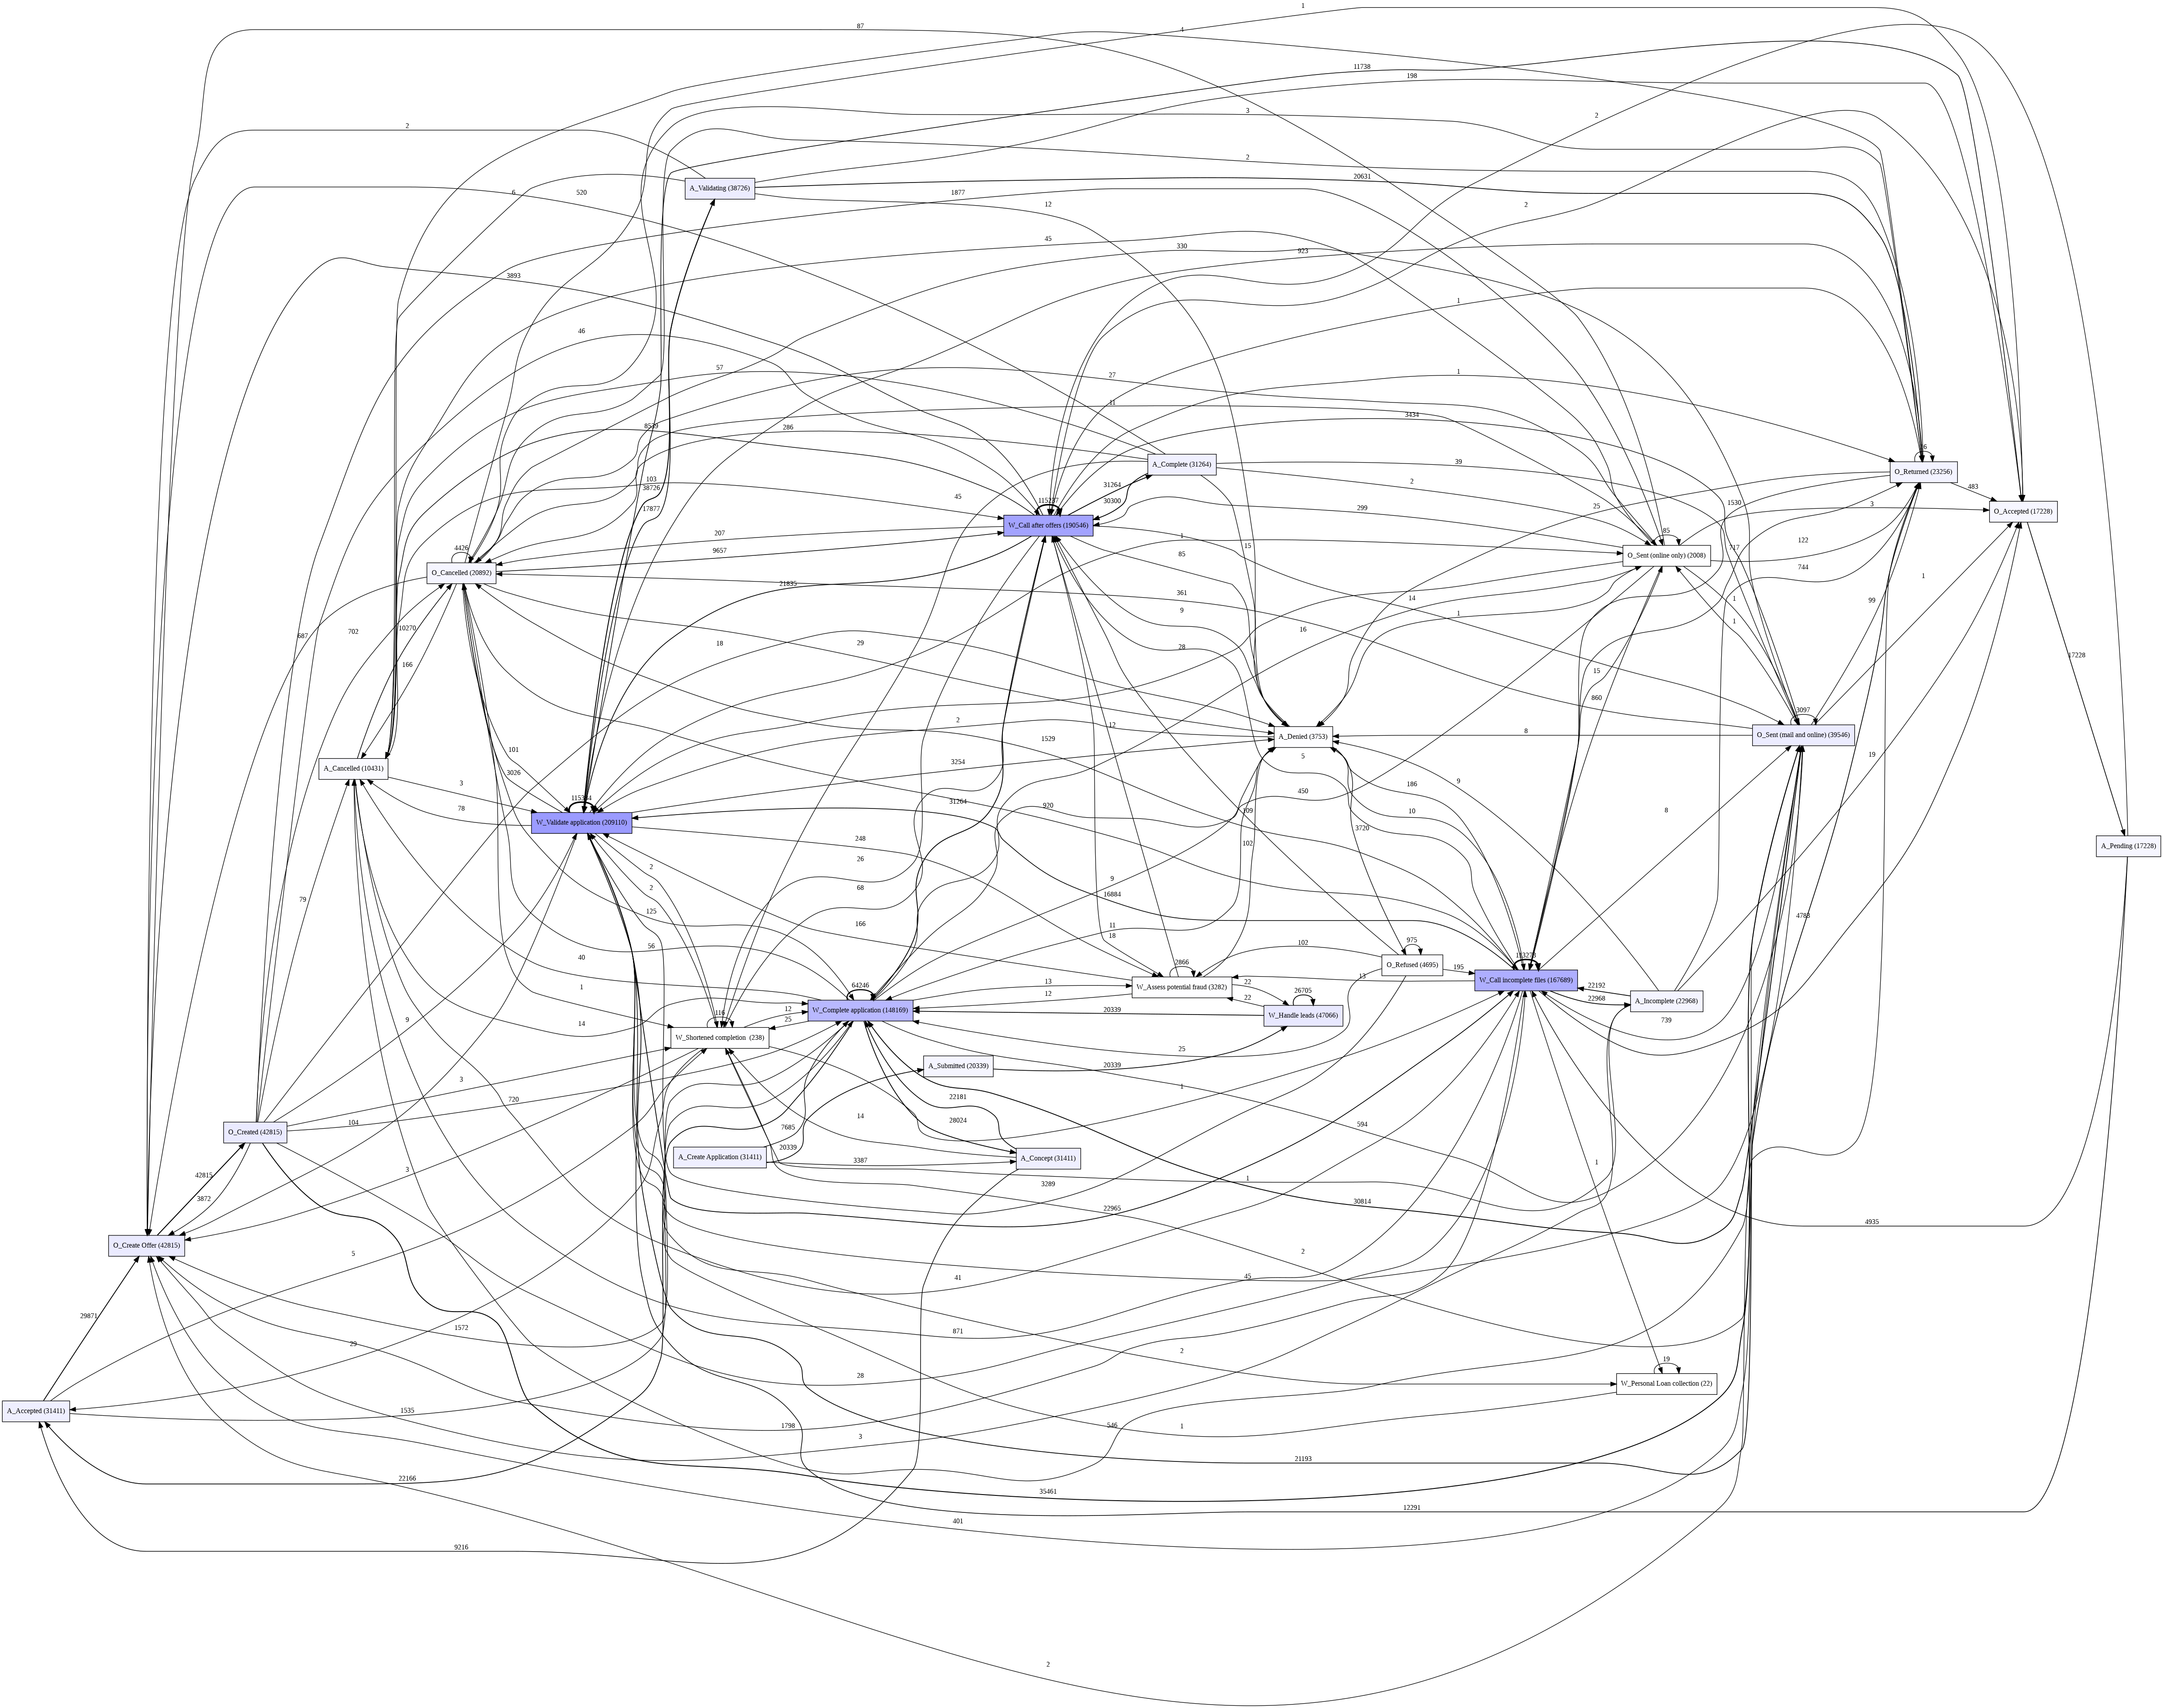

''

In [ ]:
# Convert the DataFrame
log_obj = pm4py.convert_to_event_log(df_view)

# Filter to create complete_log containing cases with final outcomes
final_activities = ['A_Pending', 'A_Cancelled', 'A_Denied']
complete_log = pm4py.objects.log.obj.EventLog()
for trace in log_obj:
    if any(event['concept:name'] in final_activities for event in trace):
        complete_log.append(trace)

# Directly-Follows Graph (DFG)
dfg, start_activities, end_activities = pm4py.discover_dfg(complete_log)

# Visualize the DFG
from pm4py.visualization.dfg import visualizer as dfg_visualizer
gviz = dfg_visualizer.apply(dfg, log=complete_log, variant=dfg_visualizer.Variants.FREQUENCY)
dfg_visualizer.view(gviz)

# Save the DFG visualization
dfg_visualizer.save(gviz, "dfg_model.png")

# **Filter Data**

After removing cases without endpoint activity: 31417 traces
Final complete cases: 31411 out of 31509 original


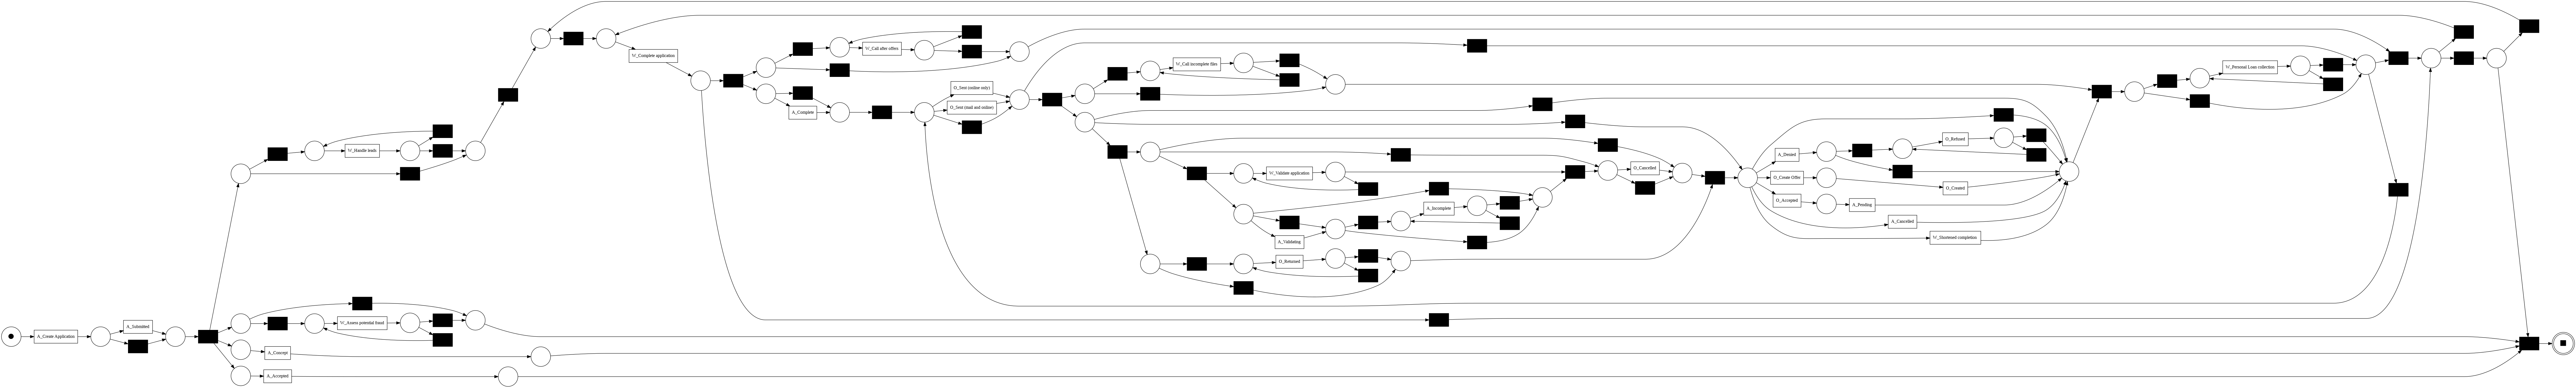

''

In [43]:
# Remove cases without any endpoint activity
end_activities = ['A_Cancelled', 'A_Denied', 'A_Pending', 'O_Cancelled', 'O_Refused']

step1_log = pm4py.objects.log.obj.EventLog()
for trace in log_obj:
    if any(event['concept:name'] in end_activities for event in trace):
        step1_log.append(trace)

print(f"After removing cases without endpoint activity: {len(step1_log)} traces")

# filter A_Pending, A_Cancelled, A_Denied
final_activities = ['A_Pending', 'A_Cancelled', 'A_Denied']

complete_log = pm4py.objects.log.obj.EventLog()
for trace in step1_log:
    if any(event['concept:name'] in final_activities for event in trace):
        complete_log.append(trace)

print(f"Final complete cases: {len(complete_log)} out of {len(log_obj)} original")

# inductive miner
net, im, fm = pm4py.discover_petri_net_inductive(complete_log)

# Visualize
from pm4py.visualization.petri_net import visualizer as pn_visualizer
gviz = pn_visualizer.apply(net, im, fm)
pn_visualizer.view(gviz)
pn_visualizer.save(gviz, "classical_petri_net_complete.png")

# **Process Discovery**

In [ ]:
def separate_log_by_prefix(input_log, prefix):
    separated_log = pm4py.objects.log.obj.EventLog()
    for trace in input_log:
        # Filter events in the trace that start with the specific prefix
        filtered_events = [e for e in trace if e['concept:name'].startswith(prefix)]

        if filtered_events:
            new_trace = pm4py.objects.log.obj.Trace()
            for event in filtered_events:
                new_trace.append(event)
            # Preserve the case attributes (like concept:name for the trace)
            new_trace.attributes.update(trace.attributes)
            separated_log.append(new_trace)
    return separated_log

# Separate the complete_log
log_A = separate_log_by_prefix(complete_log, 'A_')
log_O = separate_log_by_prefix(complete_log, 'O_')
log_W = separate_log_by_prefix(complete_log, 'W_')

print(f"Application Log (A): {len(log_A)} traces")
print(f"Offer Log (O): {len(log_O)} traces")
print(f"Workflow Log (W): {len(log_W)} traces")

Application Log (A): 31411 traces
Offer Log (O): 31411 traces
Workflow Log (W): 31411 traces


## 3 catagory A, O, and W

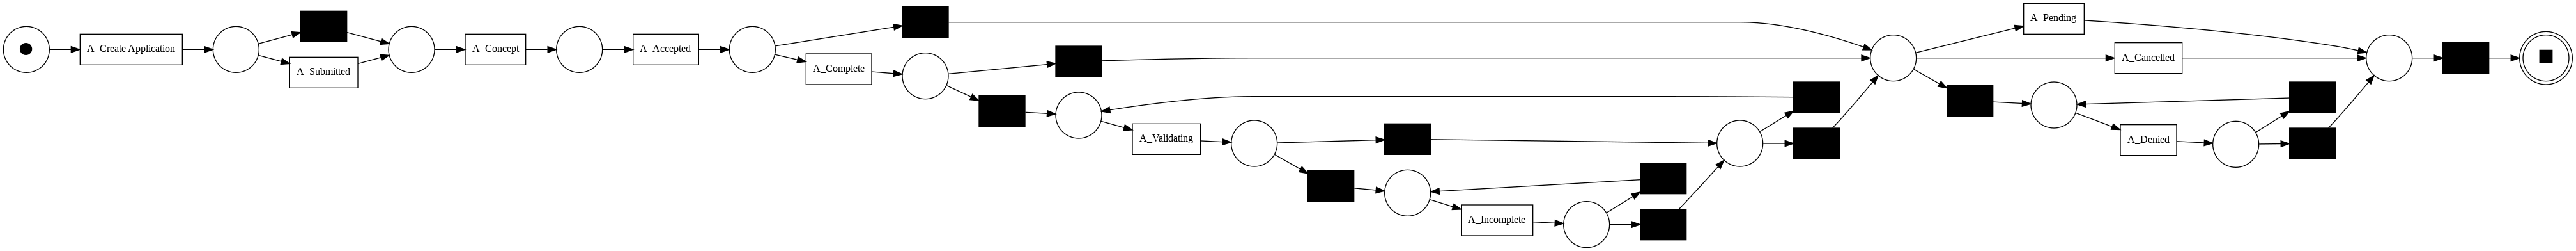

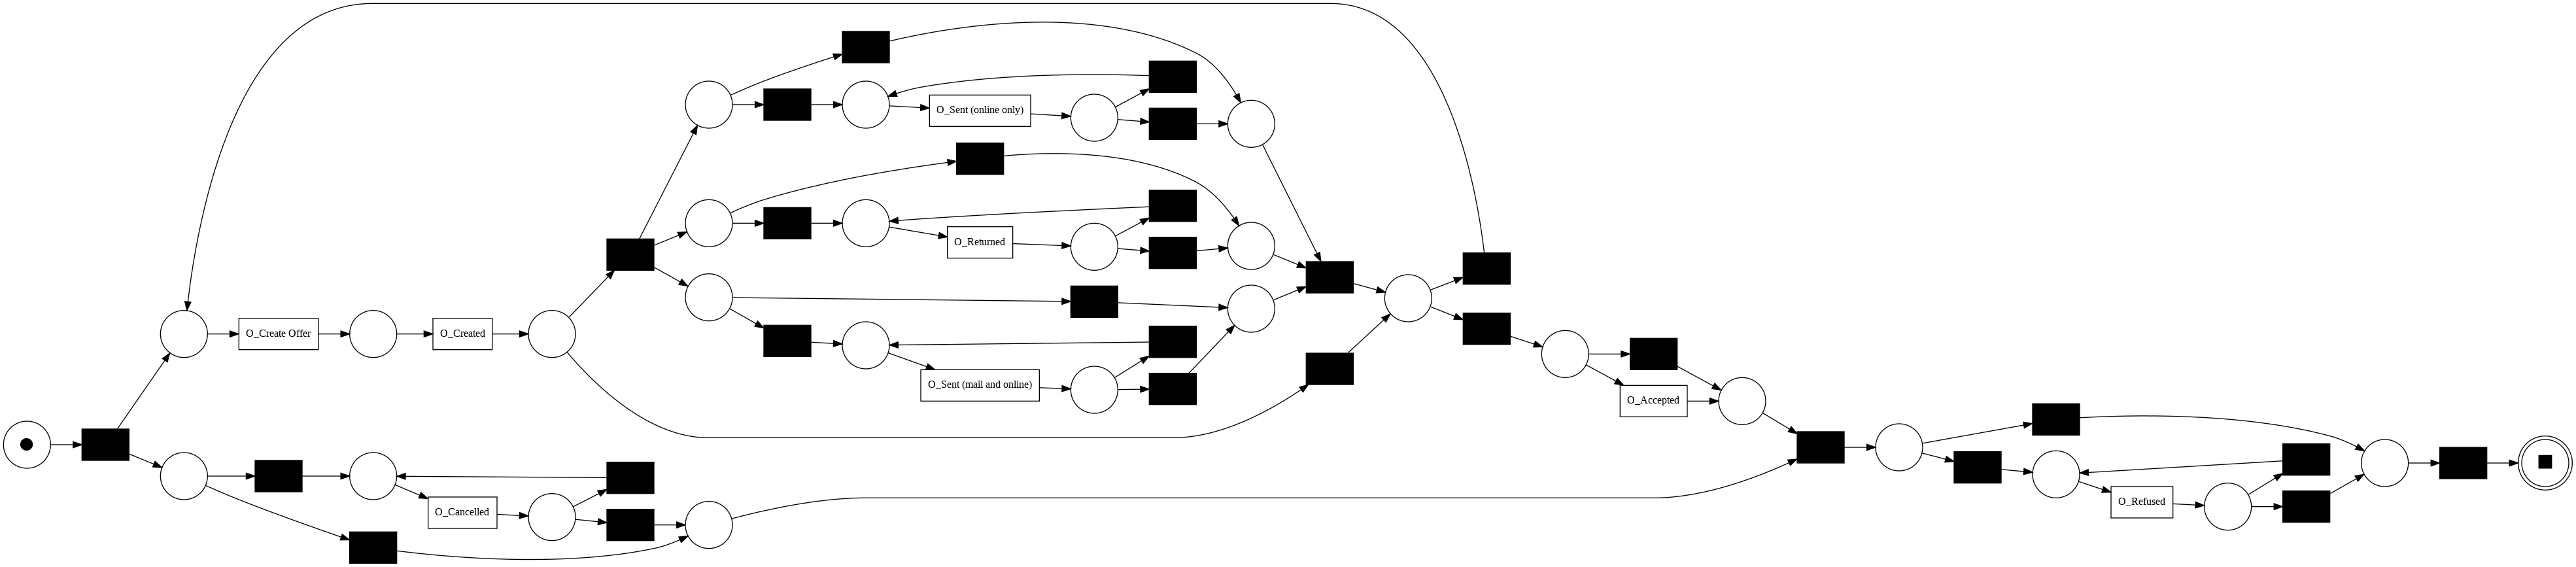

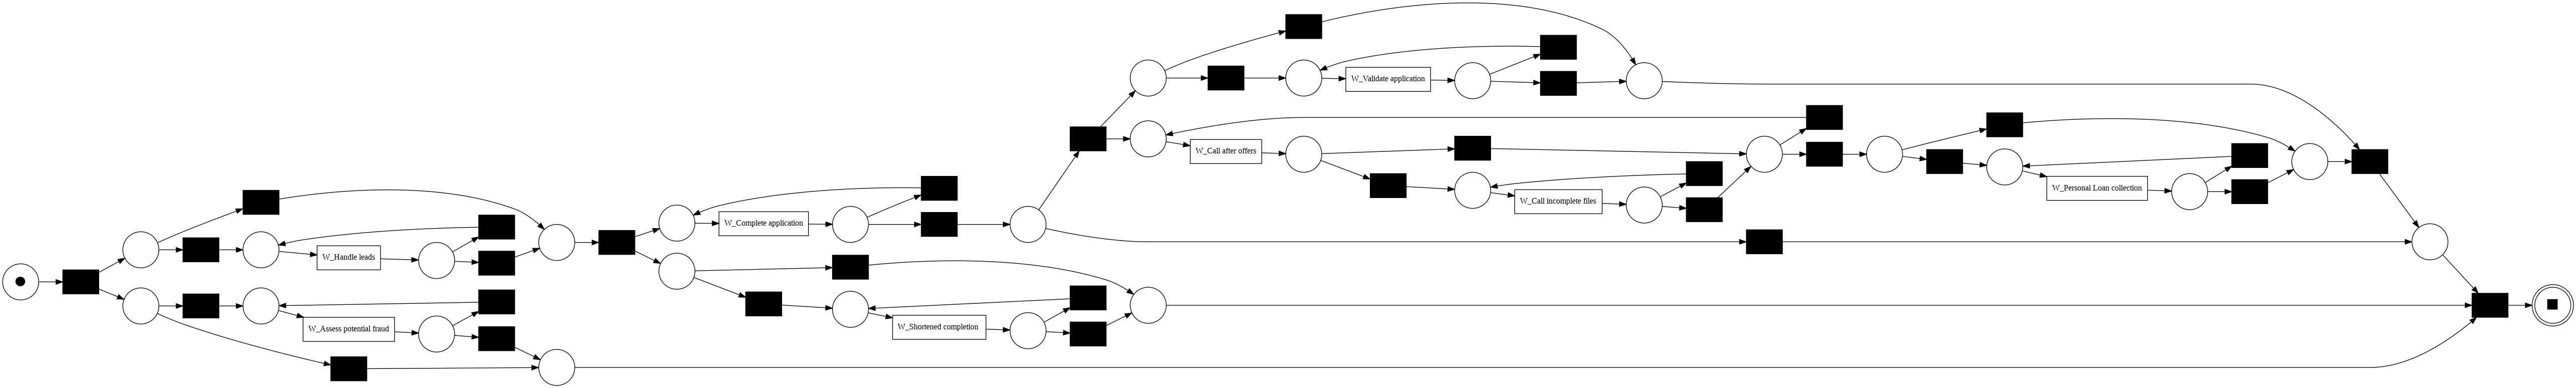

In [ ]:
# Discover Petri nets for each separate log
net_A, im_A, fm_A = pm4py.discover_petri_net_inductive(log_A)
net_O, im_O, fm_O = pm4py.discover_petri_net_inductive(log_O)
net_W, im_W, fm_W = pm4py.discover_petri_net_inductive(log_W)

# Visualize and Save models
from pm4py.visualization.petri_net import visualizer as pn_visualizer

# Process A
gviz_A = pn_visualizer.apply(net_A, im_A, fm_A)
pn_visualizer.save(gviz_A, "process_A_model.png")


# Process O
gviz_O = pn_visualizer.apply(net_O, im_O, fm_O)
pn_visualizer.save(gviz_O, "process_O_model.png")


# Process W
gviz_W = pn_visualizer.apply(net_W, im_W, fm_W)
pn_visualizer.save(gviz_W, "process_W_model.png")


# Displaying the Application model as an example
pn_visualizer.view(gviz_A)
pn_visualizer.view(gviz_O)
pn_visualizer.view(gviz_W)

## Data Flow of A, O, and W

### **Application(A)**

In [ ]:
# Get variants for log_A
variants_A = pm4py.get_variants(log_A)

# sort
variants_count_A = Counter({v: len(traces) for v, traces in variants_A.items()})
top_5_variants_A = variants_count_A.most_common(5)

print(f"Process Variants Application(log_A)\n")
for i, (variant, count) in enumerate(top_5_variants_A):
    print(f"Variant {i+1} (Occurrences: {count}):")
    print(f"Sequence: {variant}\n")

Process Variants Application(log_A)

Variant 1 (Occurrences: 6840):
Sequence: ('A_Create Application', 'A_Submitted', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Cancelled')

Variant 2 (Occurrences: 2956):
Sequence: ('A_Create Application', 'A_Submitted', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Validating', 'A_Incomplete', 'A_Validating', 'A_Pending')

Variant 3 (Occurrences: 2467):
Sequence: ('A_Create Application', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Cancelled')

Variant 4 (Occurrences: 2301):
Sequence: ('A_Create Application', 'A_Submitted', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Validating', 'A_Pending')

Variant 5 (Occurrences: 2280):
Sequence: ('A_Create Application', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Validating', 'A_Pending')



In [ ]:
# Map end activities outcomes
outcome_map = {
    'A_Pending': 'Approved',
    'A_Denied': 'Denied',
    'A_Cancelled': 'Cancelled'
}

# log_A
variants_A = pm4py.get_variants(log_A)

# Analyze outcomes
variant_outcomes = []
for variant, traces in variants_A.items():
    count = len(traces)
    last_act = variant[-1]
    outcome = outcome_map.get(last_act, 'Other')
    variant_outcomes.append({
        'sequence': variant,
        'count': count,
        'outcome': outcome
    })

# Sort
sorted_outcomes = sorted(variant_outcomes, key=lambda x: x['count'], reverse=True)

print(f"Log A Process Outcomes\n")
for i, item in enumerate(sorted_outcomes[:10]):
    print(f"Variant {i+1}:")
    print(f"  Cases: {item['count']}")
    print(f"  Outcome: {item['outcome']}")
    print(f"  Sequence: {item['sequence']}\n")

# Summary counts
summary = Counter([item['outcome'] for item in variant_outcomes for _ in range(item['count'])])
print("Summary")
for outcome, total in summary.items():
    print(f"{outcome}: {total}")

Log A Process Outcomes

Variant 1:
  Cases: 6840
  Outcome: Cancelled
  Sequence: ('A_Create Application', 'A_Submitted', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Cancelled')

Variant 2:
  Cases: 2956
  Outcome: Approved
  Sequence: ('A_Create Application', 'A_Submitted', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Validating', 'A_Incomplete', 'A_Validating', 'A_Pending')

Variant 3:
  Cases: 2467
  Outcome: Cancelled
  Sequence: ('A_Create Application', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Cancelled')

Variant 4:
  Cases: 2301
  Outcome: Approved
  Sequence: ('A_Create Application', 'A_Submitted', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Validating', 'A_Pending')

Variant 5:
  Cases: 2280
  Outcome: Approved
  Sequence: ('A_Create Application', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Validating', 'A_Pending')

Variant 6:
  Cases: 2134
  Outcome: Approved
  Sequence: ('A_Create Application', 'A_Concept', 'A_Accepted', 'A_Complete', 'A_Validating', 'A_Incomplete', 'A_Va

In [ ]:
variants_a = []
for trace in complete_log:
    for event in trace:
        act = event['concept:name']

        if act.startswith('A_'):
            variants_a.append(act)

# Count frequencies
a_counts = Counter(variants_a)

# Sort
sorted_a = sorted(a_counts.items(), key=lambda x: x[1], reverse=True)

print("Application (A) Event Frequencies:")
print("-" * 40)
for act, count in sorted_a:
    print(f"{act:<35} {count:,}")

Application (A) Event Frequencies:
----------------------------------------
A_Validating                        38,726
A_Create Application                31,411
A_Concept                           31,411
A_Accepted                          31,411
A_Complete                          31,264
A_Incomplete                        22,968
A_Submitted                         20,339
A_Pending                           17,228
A_Cancelled                         10,431
A_Denied                            3,753


### **Offer(O)**

In [ ]:
# Get variants for log_O
variants_O = pm4py.get_variants(log_O)

# Count occurrences and sort
variants_count_O = Counter({v: len(traces) for v, traces in variants_O.items()})
top_5_variants_O = variants_count_O.most_common(5)

print(f"Process Variants (log_O)\n")
for i, (variant, count) in enumerate(top_5_variants_O):
    print(f"Variant {i+1} (Occurrences: {count}):")
    print(f"Sequence: {variant}\n")

Process Variants (log_O)

Variant 1 (Occurrences: 12000):
Sequence: ('O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Returned', 'O_Accepted')

Variant 2 (Occurrences: 7101):
Sequence: ('O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Cancelled')

Variant 3 (Occurrences: 2665):
Sequence: ('O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Returned', 'O_Refused')

Variant 4 (Occurrences: 1176):
Sequence: ('O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Returned', 'O_Accepted', 'O_Cancelled')

Variant 5 (Occurrences: 802):
Sequence: ('O_Create Offer', 'O_Created', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Sent (mail and online)', 'O_Returned', 'O_Accepted', 'O_Cancelled')



In [ ]:
# Map Offer end activities to outcomes
o_outcome_map = {
    'O_Accepted': 'Approved',
    'O_Refused': 'Denied',
    'O_Cancelled': 'Cancelled'
}

# Get variants for log_O
variants_O = pm4py.get_variants(log_O)

# Analyze outcomes for offers
o_variant_outcomes = []
for variant, traces in variants_O.items():
    count = len(traces)
    last_act = variant[-1]
    outcome = o_outcome_map.get(last_act, 'Other')

    o_variant_outcomes.append({
        'sequence': variant,
        'count': count,
        'outcome': outcome
    })

# Sort by frequency
sorted_o_outcomes = sorted(o_variant_outcomes, key=lambda x: x['count'], reverse=True)

print(f"Log O (Offer) Process Outcomes\n")
for i, item in enumerate(sorted_o_outcomes[:10]):
    print(f"Variant {i+1}:")
    print(f"  Cases: {item['count']}")
    print(f"  Outcome: {item['outcome']}")
    print(f"  Sequence: {item['sequence']}\n")

# Summary
o_summary = Counter([item['outcome'] for item in o_variant_outcomes for _ in range(item['count'])])
print("Summary")
for outcome, total in o_summary.items():
    print(f"{outcome}: {total}")

Log O (Offer) Process Outcomes

Variant 1:
  Cases: 12000
  Outcome: Approved
  Sequence: ('O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Returned', 'O_Accepted')

Variant 2:
  Cases: 7101
  Outcome: Cancelled
  Sequence: ('O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Cancelled')

Variant 3:
  Cases: 2665
  Outcome: Denied
  Sequence: ('O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Returned', 'O_Refused')

Variant 4:
  Cases: 1176
  Outcome: Cancelled
  Sequence: ('O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Returned', 'O_Accepted', 'O_Cancelled')

Variant 5:
  Cases: 802
  Outcome: Cancelled
  Sequence: ('O_Create Offer', 'O_Created', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'O_Sent (mail and online)', 'O_Returned', 'O_Accepted', 'O_Cancelled')

Variant 6:
  Cases: 794
  Outcome: Cancelled
  Sequence: ('O_Create Offer', 'O_Created', 'O_Create Offe

In [ ]:
variants_O = []
for trace in complete_log:
    for event in trace:
        act = event['concept:name']

        if act.startswith('O_'):
            variants_O.append(act)

# Count frequencies
o_counts = Counter(variants_O)

# Sort by count descending
sorted_o = sorted(o_counts.items(), key=lambda x: x[1], reverse=True)

print("Offer (O) Event Frequencies:")
print("-" * 40)
for act, count in sorted_o:
    print(f"{act:<35} {count:,}")

Offer (O) Event Frequencies:
----------------------------------------
O_Create Offer                      42,815
O_Created                           42,815
O_Sent (mail and online)            39,546
O_Returned                          23,256
O_Cancelled                         20,892
O_Accepted                          17,228
O_Refused                           4,695
O_Sent (online only)                2,008


### **Workflow(W)**

In [ ]:
# Get variants for log_W
variants_W = pm4py.get_variants(log_W)

# Count occurrences and sort
variants_count_W = Counter({v: len(traces) for v, traces in variants_W.items()})
top_5_variants_W = variants_count_W.most_common(10)

print(f"Process Variants (log_W)\n")
for i, (variant, count) in enumerate(top_5_variants_W):
    print(f"Variant {i+1} (Occurrences: {count}):")
    print(f"Sequence: {variant}\n")

Process Variants (log_W)

Variant 1 (Occurrences: 1533):
Sequence: ('W_Complete application', 'W_Complete application', 'W_Complete application', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers')

Variant 2 (Occurrences: 1420):
Sequence: ('W_Handle leads', 'W_Handle leads', 'W_Complete application', 'W_Complete application', 'W_Complete application', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers')

Variant 3 (Occurrences: 980):
Sequence: ('W_Handle leads', 'W_Handle leads', 'W_Complete application', 'W_Complete application', 'W_Complete application', 'W_Complete application', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers')

Variant 4 (Occurrences: 630):
Sequence: ('W_Handle leads', 'W_Handle leads', 'W_Complete application

In [ ]:
variants_W_dict = pm4py.get_variants(log_W)
w_variant_analysis = []

for variant, traces in variants_W_dict.items():
    count = len(traces)
    has_validate = 'W_Validate application' in variant

    outcomes = Counter()
    for trace in traces:
        a_activities = [e['concept:name'] for e in trace if e['concept:name'].startswith('A_')]
        if a_activities:
            last_a_act = a_activities[-1]
            outcomes[outcome_map.get(last_a_act, 'Other')] += 1
        else:
            outcomes['Unknown'] += 1

    w_variant_analysis.append({
        'sequence': variant,
        'count': count,
        'has_validate': has_validate,
        'outcomes': outcomes
    })

# Filter
validated_variants = [v for v in w_variant_analysis if v['has_validate']]

# Sort
sorted_validated = sorted(validated_variants, key=lambda x: x['count'], reverse=True)

print(f"{'#'*1} Log W: {'#'*1}\n")
for i, item in enumerate(sorted_validated[:10]):
    full_sequence = ' -> '.join(item['sequence'])
    print(f"variant {i+1} (Cases: {item['count']})")
    print(f"Outcome: {dict(item['outcomes'])}")
    print(f"Full Sequence: {full_sequence}\n")
    print('-' * 20)

# cases
total_validated_outcomes = Counter()
for v in validated_variants:
    total_validated_outcomes.update(v['outcomes'])

print('Total Cases:')
for outcome, count in total_validated_outcomes.items():
    print(f'  {outcome}: {count}')

# Log W: #

variant 1 (Cases: 627)
Outcome: {'Unknown': 627}
Full Sequence: W_Complete application -> W_Complete application -> W_Complete application -> W_Call after offers -> W_Call after offers -> W_Call after offers -> W_Call after offers -> W_Call after offers -> W_Call after offers -> W_Validate application -> W_Validate application -> W_Validate application -> W_Validate application

--------------------
variant 2 (Cases: 430)
Outcome: {'Unknown': 430}
Full Sequence: W_Handle leads -> W_Handle leads -> W_Complete application -> W_Complete application -> W_Complete application -> W_Call after offers -> W_Call after offers -> W_Call after offers -> W_Call after offers -> W_Call after offers -> W_Call after offers -> W_Validate application -> W_Validate application -> W_Validate application -> W_Validate application

--------------------
variant 3 (Cases: 368)
Outcome: {'Unknown': 368}
Full Sequence: W_Handle leads -> W_Handle leads -> W_Complete application -> W_Complete applicati

In [ ]:
# Extract all W_ activity names from complete_log
variants_W = []
for trace in complete_log:
    for event in trace:
        act = event['concept:name']
        if act.startswith('W_'):
            variants_W.append(act)

# Count frequencies
w_counts = Counter(variants_W)

# Sort by count descending
sorted_w = sorted(w_counts.items(), key=lambda x: x[1], reverse=True)

print("Workflow (W) Event Frequencies:")
print("-" * 40)
for act, count in sorted_w:
    print(f"{act:<35} {count:,}")

Workflow (W) Event Frequencies:
----------------------------------------
W_Validate application              209,110
W_Call after offers                 190,546
W_Call incomplete files             167,689
W_Complete application              148,169
W_Handle leads                      47,066
W_Assess potential fraud            3,282
W_Shortened completion              238
W_Personal Loan collection          22


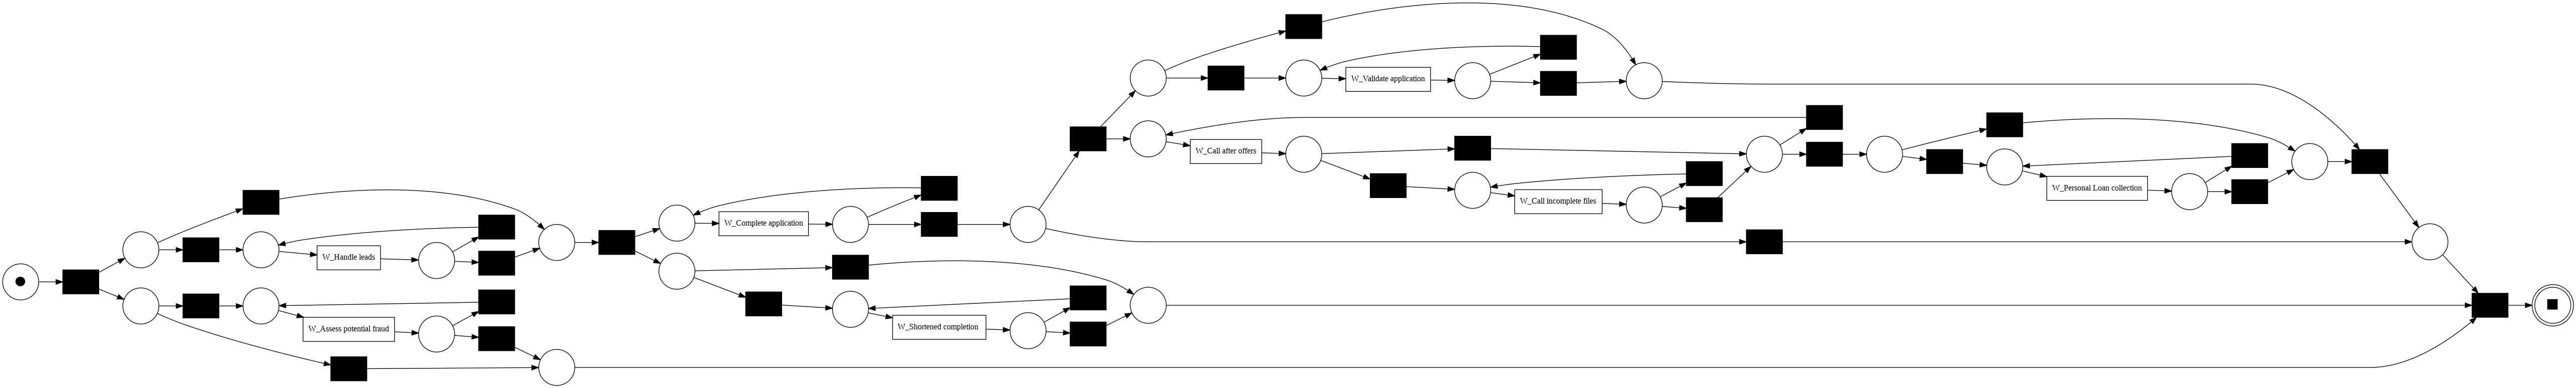

In [ ]:
gviz_W = pn_visualizer.apply(net_W, im_W, fm_W)
pn_visualizer.view(gviz_W)

--------------------------------